Importing:

In [305]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import lightgbm as lgb
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

Loading data:

In [306]:
DATA_DIR = Path("../data/processed") 
train = pd.read_csv(DATA_DIR / "train.csv")
val = pd.read_csv(DATA_DIR / "val.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

Seperate features X from target Y

In [307]:
X_train = train.drop(columns=["label"])
Y_train = train["label"]

X_val = val.drop(columns=["label"])
Y_val = val["label"]

X_test = test.drop(columns=["label"])
Y_test = test["label"]

Convert boolean columns to integers:

In [308]:
bool_cols = X_train.select_dtypes(include=["bool"]).columns
if len(bool_cols) > 0:
    X_train[bool_cols] = X_train[bool_cols].astype(int)
    X_val[bool_cols] = X_val[bool_cols].astype(int)
    X_test[bool_cols] = X_test[bool_cols].astype(int)

Vertifying the shapes:

In [309]:
print(f"Training set: X shape = {X_train.shape}, y shape = {Y_train.shape}")
print(f"Validation set: X shape = {X_val.shape}, y shape = {Y_val.shape}")
print(f"Test set: X shape = {X_test.shape}, y shape = {Y_test.shape}")
print(f"\nNumber of features: {X_train.shape[1]}")
print(f"Target distribution (train):\n{Y_train.value_counts()}")

Training set: X shape = (35364, 25), y shape = (35364,)
Validation set: X shape = (7660, 25), y shape = (7660,)
Test set: X shape = (15990, 25), y shape = (15990,)

Number of features: 25
Target distribution (train):
label
1    17682
0    17682
Name: count, dtype: int64


24 features/columns make sense, as there's total of 25 columns including "label"

Now let's get into LightGBM

In [310]:
model = lgb.LGBMClassifier(
    objective='binary',           # Binary classification (win/loss)
    metric='binary_logloss',      # Metric to optimize during training
    n_estimators=200,              # Number of trees (start small)
    learning_rate=0.05,             # How fast the model learns (0.1 is a good default)
    max_depth=5,                   # Maximum depth of trees (controls complexity)
    # reg_alpha=0.1,                 # L1 regularization
    # reg_lambda=0.1,                # L2 regularization
    random_state=42,               # For reproducibility
    verbose=-1                     # Suppress output during training
)

Now I will train my baseline model (M_0):

In [311]:
model.fit(
    X_train, 
    Y_train,
    eval_set=[(X_val, Y_val)],  # Monitor validation performance
    eval_names=['validation'],   # Name for the evaluation set
    callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=True)]  # Stop if no improvement after 10 rounds
)

Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[64]	validation's binary_logloss: 0.624365


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.05
,n_estimators,200
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [312]:
# Make predictions on validation set
# Binary predictions (0 or 1)
y_val_pred = model.predict(X_val)

# Probability predictions (0.0 to 1.0)
y_val_prob = model.predict_proba(X_val)[:, 1]  # [:, 1] gets P(win)

print(f"First 10 binary predictions: {y_val_pred[:10]}")
print(f"First 10 probabilities: {y_val_prob[:10]}")

First 10 binary predictions: [0 1 1 0 1 0 0 1 1 0]
First 10 probabilities: [0.48370754 0.54277909 0.62299566 0.38234573 0.63581345 0.32463889
 0.39403055 0.59574517 0.8102984  0.20626502]


These show clear imperfections, as they don't add up to 100% between two predictions and is different from validation data.

Let's find out the validation accuracy:

In [313]:
val_accuracy = accuracy_score(Y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

Validation Accuracy: 0.6415 (64.15%)


Not the greatest, but this is better than 50% odd

Now, we will evaluate the model with AUC-ROC

In [314]:
val_auc = roc_auc_score(Y_val, y_val_prob)
print(f"Validation AUC-ROC: {val_auc:.4f}")

Validation AUC-ROC: 0.7029


This is a reasonable baseline. Now we will make a confusion matrix

In [315]:
cm = confusion_matrix(Y_val, y_val_pred)
print(f"\nConfusion Matrix:")
print(f"True Negatives (correct losses):  {cm[0,0]}")
print(f"False Positives (predicted win, actual loss): {cm[0,1]}")
print(f"False Negatives (predicted loss, actual win): {cm[1,0]}")
print(f"True Positives (correct wins):    {cm[1,1]}")


Confusion Matrix:
True Negatives (correct losses):  2465
False Positives (predicted win, actual loss): 1365
False Negatives (predicted loss, actual win): 1381
True Positives (correct wins):    2449


The Confusion Matrix shows # of correct and failed predictions

I will also check for overfitting by evaluating the training set

In [316]:
y_train_pred = model.predict(X_train)
y_train_proba = model.predict_proba(X_train)[:, 1]
train_accuracy = accuracy_score(Y_train, y_train_pred)
train_auc = roc_auc_score(Y_train, y_train_proba)

print(f"\nTraining Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Training AUC-ROC: {train_auc:.4f}")

# Check for overfitting
print(f"\nOverfitting check:")
print(f"Train-Val Accuracy gap: {train_accuracy - val_accuracy:.4f}")
print(f"Train-Val AUC gap: {train_auc - val_auc:.4f}")


Training Accuracy: 0.6721 (67.21%)
Training AUC-ROC: 0.7431

Overfitting check:
Train-Val Accuracy gap: 0.0306
Train-Val AUC gap: 0.0402


As train is higher than validation, this means the model slightly generalizes and overfits. But the difference isn't too high to add in L1 and L2 regularization

Before testing, we will move onto feature importance:

Top 10 Most Important Features:
             feature  importance
    rank_points_diff         349
           rank_diff         168
            age_diff         159
          player_age         126
  player_rank_points         121
         height_diff         116
        opponent_age         113
opponent_rank_points         110
             best_of          89
                year          86


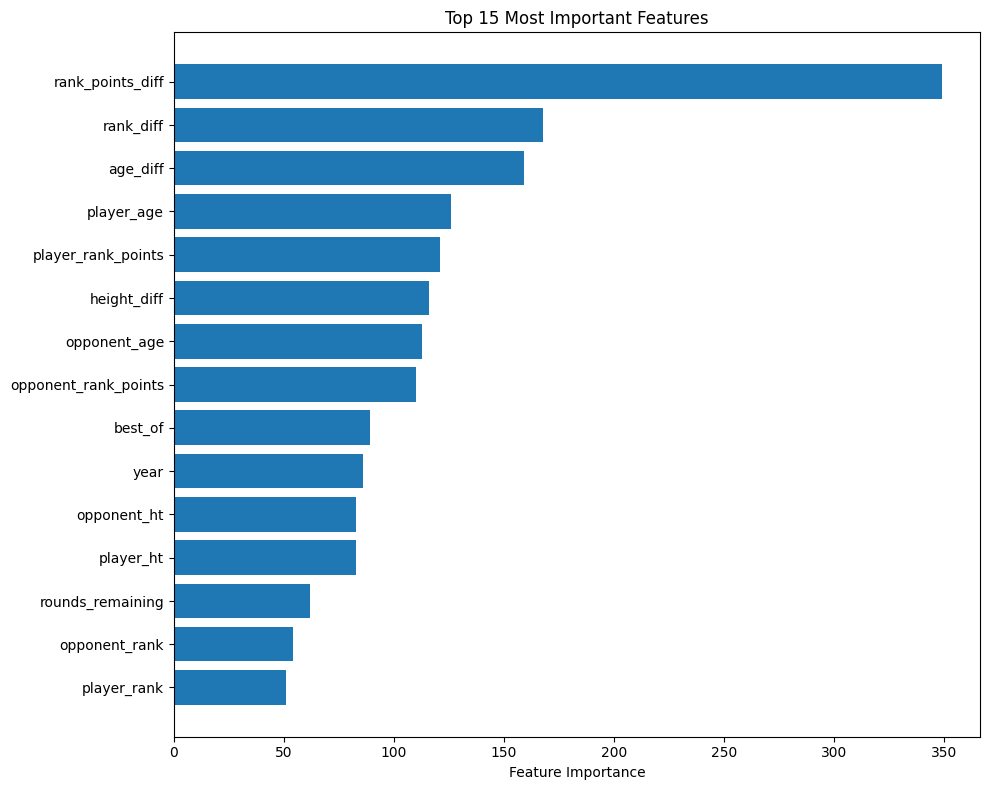


All 25 features sorted by importance:
             feature  importance
    rank_points_diff         349
           rank_diff         168
            age_diff         159
          player_age         126
  player_rank_points         121
         height_diff         116
        opponent_age         113
opponent_rank_points         110
             best_of          89
                year          86
         opponent_ht          83
           player_ht          83
    rounds_remaining          62
       opponent_rank          54
         player_rank          51
               month          39
       surface_Grass          21
     tourney_level_M          13
        surface_Clay          10
      player_is_left           9
    opponent_is_left           9
     tourney_level_A           3
     tourney_level_F           0
     tourney_level_G           0
     tourney_level_O           0


In [317]:

feature_importance = model.feature_importances_            

feature_df = pd.DataFrame({                 #new df with feature names and importance scores
    'feature': X_train.columns,
    'importance': feature_importance
})

feature_df = feature_df.sort_values('importance', ascending=False)          #sort highest to lowest

print("Top 10 Most Important Features:")
print(feature_df.head(10).to_string(index=False))

#Visualization
plt.figure(figsize=(10, 8))
top_n = 15  # Show top 15 features
top_features = feature_df.head(top_n)

plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title(f'Top {top_n} Most Important Features')
plt.gca().invert_yaxis()  # Highest importance at top
plt.tight_layout()
plt.show()

print(f"\nAll {len(feature_df)} features sorted by importance:")
print(feature_df.to_string(index=False))

Difference features dominates the top 6 most importance features, suggesting that relative advantage matters more than absolute values. 

It also shows the feature engineering worked as it should.

Also explored Random Search but did not perform well.

## Final Evaluation on Test Set


In [318]:
final_model = model  # or best_model if you saved it

# Make predictions on test set
y_test_pred = final_model.predict(X_test)
y_test_proba = final_model.predict_proba(X_test)[:, 1]

# Calculate metrics
test_accuracy = accuracy_score(Y_test, y_test_pred)
test_auc = roc_auc_score(Y_test, y_test_proba)

# Confusion matrix
cm_test = confusion_matrix(Y_test, y_test_pred)

# Print results
print("=" * 60)
print("FINAL TEST SET EVALUATION")
print("=" * 60)
print(f"\nTest Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test AUC-ROC: {test_auc:.4f}")

print(f"\nTest Confusion Matrix:")
print(f"True Negatives (correct losses):  {cm_test[0,0]}")
print(f"False Positives (predicted win, actual loss): {cm_test[0,1]}")
print(f"False Negatives (predicted loss, actual win): {cm_test[1,0]}")
print(f"True Positives (correct wins):    {cm_test[1,1]}")

# Compare with validation performance
print(f"\n" + "=" * 60)
print("COMPARISON: Validation vs Test")
print("=" * 60)
print(f"Validation Accuracy: 0.6411 (64.15%)")
print(f"Test Accuracy:       {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Difference:          {test_accuracy - 0.6415:.4f}")

print(f"\nValidation AUC-ROC: 0.7029")
print(f"Test AUC-ROC:       {test_auc:.4f}")
print(f"Difference:         {test_auc - 0.7029:.4f}")

# Check for overfitting to validation set
if abs(test_auc - 0.7029) > 0.05:
    print(f"Large gap between validation and test performance!")
    print(f"   This suggests possible overfitting to validation set.")
else:
    print(f"\nModel generalizes well to test set!")

FINAL TEST SET EVALUATION

Test Accuracy: 0.6440 (64.40%)
Test AUC-ROC: 0.7013

Test Confusion Matrix:
True Negatives (correct losses):  5154
False Positives (predicted win, actual loss): 2841
False Negatives (predicted loss, actual win): 2852
True Positives (correct wins):    5143

COMPARISON: Validation vs Test
Validation Accuracy: 0.6411 (64.15%)
Test Accuracy:       0.6440 (64.40%)
Difference:          0.0025

Validation AUC-ROC: 0.7029
Test AUC-ROC:       0.7013
Difference:         -0.0016

Model generalizes well to test set!


Note that for tennis AUC-ROC matters more. I would want to know how confident the model is. So, 0.7026 is a solid baseline for tennis match predictions